# Setup smoke test

Verify Tidy3D installation, authentication, and a minimal straight-waveguide FDTD job on the cloud.

**Prerequisites:** `pip install -e ".[dev]"` and `tidy3d configure`.

In [1]:
import tidy3d as td
import tidy3d.web as web
import matplotlib.pyplot as plt

from fdtd_pic.config import FREQ0, FWIDTH, HEIGHT, WAVELENGTH
from fdtd_pic.materials import si_medium, sio2_medium

print('Tidy3D', td.__version__)
acct = web.account(verbose=False)
print('Account:', acct)

Tidy3D 2.11.2
Account: allowance_cycle_type='Monthly' credit=14.0 credit_expiration=datetime.datetime(2027, 7, 7, 23, 59, 59, 999999, tzinfo=TzInfo(0)) allowance_current_cycle_amount=9.975 allowance_current_cycle_end_date=datetime.datetime(2026, 7, 31, 23, 59, 59, 999000, tzinfo=TzInfo(0)) daily_free_simulation_counts=0 allowanceCurrentCycleTotalAmount=10


In [2]:
import sys
print(sys.executable)
import fdtd_pic
import tidy3d

/workspaces/fdtd-pic-simulations/.venv/bin/python


14:25:37 UTC WARNING: Structure: simulation.structures[0] (no `name` was        
             specified) was detected as being less than half of a central       
             wavelength from a PML on side z-min. To avoid inaccurate results or
             divergence, please increase gap between any structures and PML or  
             fully extend structure through the pml.                            

             WARNING: Suppressed 1 WARNING message.                             

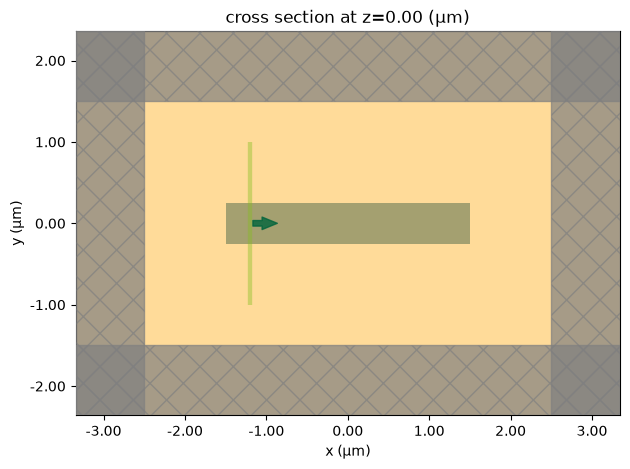

In [4]:
# Minimal straight waveguide FDTD (docs-style smoke test)
width = 0.5
sim_size = (5.0, 3.0, HEIGHT + 1.0)
wg = td.Structure(
    geometry=td.Box(center=(0, 0, 0), size=(3.0, width, HEIGHT)),
    medium=si_medium(),
)
sim = td.Simulation(
    size=sim_size,
    structures=[wg],
    sources=[
        td.ModeSource(
            center=(-1.2, 0, 0),
            size=(0, 2.0, HEIGHT + 1.0),
            source_time=td.GaussianPulse(freq0=FREQ0, fwidth=FWIDTH),
            direction='+',
            mode_spec=td.ModeSpec(num_modes=1),
        )
    ],
    monitors=[
        td.FieldMonitor(center=(0, 0, 0), size=(td.inf, td.inf, 0), freqs=[FREQ0], name='field')
    ],
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=15, wavelength=WAVELENGTH),
    run_time=1e-12,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    medium=sio2_medium(),
)
sim.plot(z=0)
plt.show()

In [ ]:
#Submit to cloud (uncomment when authenticated) - yes
sim_data = web.run(sim, task_name='smoke_straight_wg', path='smoke_straight_wg.hdf5', verbose=True)
sim_data.plot_field('field', 'E', 'abs^2')
plt.show()

14:29:46 UTC WARNING: Structure: simulation.structures[0] (no `name` was        
             specified) was detected as being less than half of a central       
             wavelength from a PML on side z-min. To avoid inaccurate results or
             divergence, please increase gap between any structures and PML or  
             fully extend structure through the pml.                            

             WARNING: Suppressed 1 WARNING message.                             

             WARNING: Structure: simulation.structures[0] (no `name` was        
             specified) was detected as being less than half of a central       
             wavelength from a PML on side z-min. To avoid inaccurate results or
             divergence, please increase gap between any structures and PML or  
             fully extend structure through the pml.                            

             WARNING: Suppressed 1 WARNING message.                             

             WARNING: Structure: simulation.structures[0] (no `name` was        
             specified) was detected as being less than half of a central       
             wavelength from a PML on side z-min. To avoid inaccurate results or
             divergence, please increase gap between any structures and PML or  
             fully extend structure through the pml.                            

...

             WARNING: Suppressed 1 WARNING message.                             

14:29:47 UTC Created task 'smoke_straight_wg' with resource_id                  
             'fdve-a2286138-4383-486c-8149-f05ba18a1c3a' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=4963072;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a2286138-4383-486c-8149-f05ba18a1c3a\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=4963073;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a2286138-4383-486c-8149-f05ba18a1c3a\taskId]8;;\]8;id=4963072;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a2286138-4383-486c-8149-f05ba18a1c3a\=]8;;\]8;id=4963074;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a2286138-4383-486c-8149-f05ba18a1c3a\fdve]8;;\]8;id=4963072;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a2286138-4383-486c-8149-f05ba18a1c3a\-a2286138-438]8;;\
             ]8;id=4963072;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a2286138-4383-486c-8149-f05ba18a1c3a\3-486c-8149-f05ba18a1c3a']8;;\.

             Task folder: ]8;id=4963077;https://tidy3d.simulation.cloud/folders/folder-dc720beb-ec56-4dcf-ac67-1ac5dac8b8d3\'default']8;;\.

Output()

## Key takeaway

If credits print and the geometry plot looks correct, the pipeline is ready for Modules 1–3. Local mode solving (no cloud) is available via `python scripts/smoke_test.py`. --- done and sorted, this is cool !

14:52:24 UTC WARNING: Structure: simulation.structures[0] (no `name` was        
             specified) was detected as being less than half of a central       
             wavelength from a PML on side z-min. To avoid inaccurate results or
             divergence, please increase gap between any structures and PML or  
             fully extend structure through the pml.                            

             WARNING: Suppressed 1 WARNING message.                             

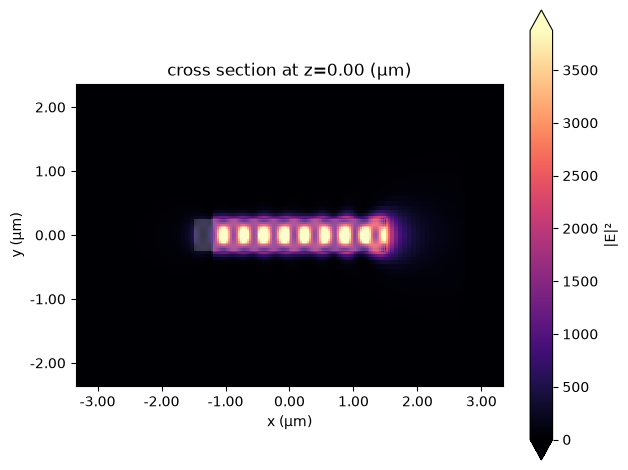

In [5]:
import tidy3d as td
import matplotlib.pyplot as plt

sim_data = td.SimulationData.from_file("smoke_straight_wg.hdf5")
sim_data.plot_field("field", "E", "abs^2")
plt.show()

14:55:53 UTC WARNING: Structure: simulation.structures[0] (no `name` was        
             specified) was detected as being less than half of a central       
             wavelength from a PML on side z-min. To avoid inaccurate results or
             divergence, please increase gap between any structures and PML or  
             fully extend structure through the pml.                            

             WARNING: Suppressed 1 WARNING message.                             

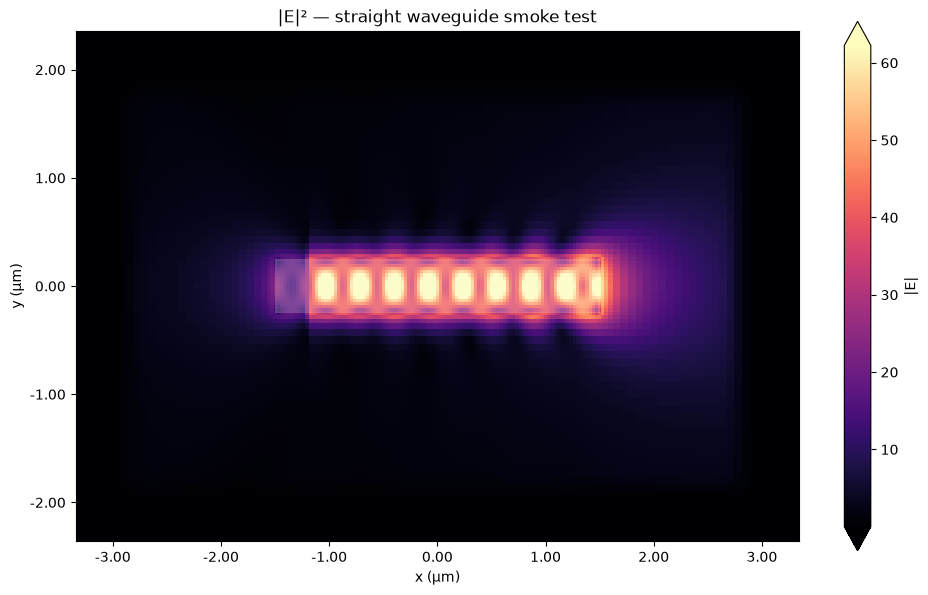

In [ ]:
import matplotlib.pyplot as plt
import tidy3d as td

sim_data = td.SimulationData.from_file("smoke_straight_wg.hdf5")

fig, ax = plt.subplots(figsize=(10, 6))
sim_data.plot_field("field", "E", "abs", ax=ax, robust=True)
ax.set_title("E — straight waveguide smoke test")
fig.tight_layout()
fig.savefig("smoke_field_log.png", dpi=300, bbox_inches="tight")
plt.show()